In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import rna_utils as ru

DATA_PATH    = "/home/gkulemeyer/Documents/Repos/RNA-analysis/DataAnalysis/data/"
 
DIST_PATH    = DATA_PATH + "rnadist_f_all.h5"
dist100_PATH = DATA_PATH + "hc_filtered100.h5"
dist200_PATH = DATA_PATH + "hc_filtered200.h5"
dist400_PATH = DATA_PATH + "hc_filtered400.h5"
META_PATH    = DATA_PATH + "sources/ArchiveII_with_prob_and_motiv.csv"

In [2]:
dist, meta = ru.load_and_align(corr_path=DIST_PATH, meta_path=META_PATH)
dist100, meta100 = ru.load_and_align(corr_path=dist100_PATH, meta_path=META_PATH)
dist200, meta200 = ru.load_and_align(corr_path=dist200_PATH, meta_path=META_PATH)
dist400, meta400 = ru.load_and_align(corr_path=dist400_PATH, meta_path=META_PATH)

print(meta400.groupby("fam")["sequence"].count())

fam
16s            66
23s            15
5s            400
RNaseP        396
grp1           74
srp           400
tRNA          175
telomerase     35
tmRNA         349
Name: sequence, dtype: int64


In [3]:

def get_min_mean(fam):
    min_dists = ru.table_min_inter_fam(fam)
    mean_dists = ru.table_inter_fam(fam)
    df_min = pd.DataFrame.from_dict(min_dists, orient="index")
    df_mean = pd.DataFrame.from_dict(mean_dists, orient="index")
    return df_min, df_mean

def make_long_df(df, value_name="Distancia"):
    df_long = df.reset_index().melt(
        id_vars="index", var_name="Familia", value_name=value_name
    )
    df_long.rename(columns={"index": "Condición"}, inplace=True)
    return df_long


def reorder_df_by_diagonal(df, fixed_order=True):
    fixed_labels = [
    "telomerase",
    "5s",
    "tRNA",
    "tmRNA",
    "RNaseP",
    "23s",
    "grp1",
    "srp",
    "16s",
    ]
    # Asegurarse de que el índice y las columnas coincidan
    common = df.index.intersection(df.columns)
    # Obtener los valores diagonales
    diagonal = df.loc[common, common].values.diagonal()
    # Crear un orden basado en la diagonal (de mayor a menor)
    ordered_labels = common[np.argsort(-diagonal)]  # el "-" es para ordenar descendente
    # Reordenar el DataFrame
    if fixed_order:
        df_sorted = df.loc[fixed_labels, fixed_labels]
    else:
        df_sorted = df.loc[ordered_labels, ordered_labels]
    return df_sorted


In [4]:
d_norm = dist / dist.max().max()
d100_norm = dist100 / dist.max().max()
d200_norm = dist200 / dist.max().max()
d400_norm = dist400 / dist.max().max()

# fams_400 = ru.build_inter_fam_corrs(dist400, meta400)
# fams_200 = ru.build_inter_fam_corrs(dist200, meta200)
# fams_100 = ru.build_inter_fam_corrs(dist100, meta100)
# fams = ru.build_inter_fam_corrs(dist, meta)  
fams = ru.build_inter_fam_corrs(d_norm, meta)
fams_100 = ru.build_inter_fam_corrs(d100_norm, meta100)
fams_200 = ru.build_inter_fam_corrs(d200_norm, meta200)
fams_400 = ru.build_inter_fam_corrs(d400_norm, meta400)


df_min_400, df_mean_400 = get_min_mean(fams_400)
df_min_200, df_mean_200 = get_min_mean(fams_200)
df_min_100, df_mean_100 = get_min_mean(fams_100)
df_min, df_mean = get_min_mean(fams)  


df_long_mean_400 = make_long_df(df_mean_400, value_name="Distancia")
df_long_min_400 = make_long_df(df_min_400, value_name="Distancia")
df_long_mean_200 = make_long_df(df_mean_200, value_name="Distancia")
df_long_min_200 = make_long_df(df_min_200, value_name="Distancia")
df_long_mean_100 = make_long_df(df_mean_100, value_name="Distancia")
df_long_min_100 = make_long_df(df_min_100, value_name="Distancia")


df_sorted_mean_400 = reorder_df_by_diagonal(df_mean_400,fixed_order=True)
df_sorted_mean_200 = reorder_df_by_diagonal(df_mean_200,fixed_order=True)
df_sorted_mean_100 = reorder_df_by_diagonal(df_mean_100,fixed_order=True)
df_sorted_min_400 = reorder_df_by_diagonal(df_min_400,  fixed_order=True)
df_sorted_min_200 = reorder_df_by_diagonal(df_min_200, fixed_order=True)
df_sorted_min_100 = reorder_df_by_diagonal(df_min_100, fixed_order=True)
df_sorted_mean = reorder_df_by_diagonal(df_mean, fixed_order=True)
df_sorted_min = reorder_df_by_diagonal(df_min, fixed_order=True)

In [5]:
for f in fams_400.keys():
    print(6 * f"---{f}---")
    display(ru.summary_table(fams_400[f]))

---16s------16s------16s------16s------16s------16s---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,66,0.449483,0.009904,0.905051
1,23s,66,0.530874,0.448547,0.645441
2,5s,66,0.528190,0.309599,0.860295
3,RNaseP,66,0.497186,0.292638,0.697942
4,grp1,66,0.509631,0.304762,0.739901
5,srp,66,0.552192,0.123671,0.964724
6,tRNA,66,0.577405,0.350685,0.795649
7,telomerase,66,0.523643,0.349286,0.634423
8,tmRNA,66,0.530088,0.280226,0.820513


---23s------23s------23s------23s------23s------23s---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,15,0.524716,0.409364,0.652946
1,23s,15,0.406968,0.005470,0.586614
2,5s,15,0.538579,0.470156,0.591004
3,RNaseP,15,0.527924,0.402442,0.686247
4,grp1,15,0.516183,0.384860,0.665047
5,srp,15,0.565865,0.404211,0.785130
6,tRNA,15,0.544838,0.461341,0.610058
7,telomerase,15,0.546028,0.471446,0.637706
8,tmRNA,15,0.544929,0.396444,0.761307


---5s------5s------5s------5s------5s------5s---


...

,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,175,0.588260,0.515989,0.790676
1,23s,175,0.540695,0.487787,0.585284
2,5s,175,0.410085,0.278519,0.596825
3,RNaseP,175,0.562191,0.420741,0.631277
4,grp1,175,0.597394,0.528254,0.647870
5,srp,175,0.541473,0.272154,0.838363
6,tRNA,175,0.133386,0.007646,0.518095
7,telomerase,175,0.632442,0.612449,0.648835
8,tmRNA,175,0.563179,0.278867,0.639614


---telomerase------telomerase------telomerase------telomerase------telomerase------telomerase---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,35,0.530620,0.345200,0.692913
1,23s,35,0.547992,0.471446,0.634579
2,5s,35,0.573753,0.511926,0.611724
3,RNaseP,35,0.557241,0.384855,0.695180
4,grp1,35,0.544265,0.420346,0.646719
5,srp,35,0.592222,0.381528,0.726404
6,tRNA,35,0.627112,0.590111,0.652318
7,telomerase,35,0.206336,0.001602,0.358242
8,tmRNA,35,0.533805,0.313561,0.626924


---tmRNA------tmRNA------tmRNA------tmRNA------tmRNA------tmRNA---


,Fam,n_seq,mean_dist,min_dist,max_dist
0,16s,349,0.527494,0.339753,0.653986
1,23s,349,0.539795,0.425517,0.624289
2,5s,349,0.570461,0.331034,0.687006
3,RNaseP,349,0.489465,0.243667,0.813468
4,grp1,349,0.495944,0.375681,0.661033
5,srp,349,0.588098,0.313725,0.909076
6,tRNA,349,0.562843,0.278867,0.635690
7,telomerase,349,0.537074,0.425137,0.605430
8,tmRNA,349,0.223470,0.001787,0.596610


In [6]:
print("min") 
display(df_min_400)

print("mean") 
display(df_mean_400)

min


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
16s,0.009904,0.448547,0.309599,0.292638,0.304762,0.123671,0.350685,0.349286,0.280226
23s,0.409364,0.005470,0.470156,0.402442,0.384860,0.404211,0.461341,0.471446,0.396444
5s,0.375038,0.490806,0.012156,0.389418,0.508899,0.276543,0.290370,0.543572,0.334283
RNaseP,0.351920,0.464957,0.389418,0.001809,0.340597,0.325926,0.397037,0.389964,0.291968
grp1,0.277268,0.426667,0.436825,0.309542,0.000000,0.293578,0.498789,0.404543,0.273504
srp,0.227556,0.460007,0.285714,0.305257,0.349032,0.054701,0.250206,0.437464,0.250980
tRNA,0.515989,0.487787,0.278519,0.420741,0.528254,0.272154,0.007646,0.612449,0.278867
telomerase,0.345200,0.471446,0.511926,0.384855,0.420346,0.381528,0.590111,0.001602,0.313561
tmRNA,0.339753,0.425517,0.331034,0.243667,0.375681,0.313725,0.278867,0.425137,0.001787


mean


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
16s,0.449483,0.530874,0.528190,0.497186,0.509631,0.552192,0.577405,0.523643,0.530088
23s,0.524716,0.406968,0.538579,0.527924,0.516183,0.565865,0.544838,0.546028,0.544929
5s,0.532668,0.534764,0.145733,0.519473,0.569286,0.513170,0.412025,0.578913,0.573035
RNaseP,0.507131,0.530970,0.524257,0.342883,0.496626,0.602154,0.565710,0.561968,0.492771
grp1,0.514300,0.526472,0.566325,0.490026,0.359681,0.602607,0.592609,0.540317,0.499318
srp,0.564592,0.566897,0.510935,0.605830,0.607662,0.420097,0.536303,0.597896,0.592859
tRNA,0.588260,0.540695,0.410085,0.562191,0.597394,0.541473,0.133386,0.632442,0.563179
telomerase,0.530620,0.547992,0.573753,0.557241,0.544265,0.592222,0.627112,0.206336,0.533805
tmRNA,0.527494,0.539795,0.570461,0.489465,0.495944,0.588098,0.562843,0.537074,0.223470


In [7]:
print("min")
print(df_min_400.shape)
display(df_min_400.describe())
print("mean")
print(df_mean_400.shape)
display(df_mean_400.describe())

min
(9, 9)


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.316888,0.409023,0.336150,0.305597,0.356937,0.271782,0.347228,0.403940,0.269069
std,0.140497,0.153100,0.147223,0.128574,0.153317,0.113925,0.169600,0.171086,0.108966
min,0.009904,0.005470,0.012156,0.001809,0.000000,0.054701,0.007646,0.001602,0.001787
25%,0.277268,0.426667,0.285714,0.292638,0.340597,0.272154,0.278867,0.389964,0.273504
50%,0.345200,0.460007,0.331034,0.309542,0.375681,0.293578,0.350685,0.425137,0.280226
75%,0.375038,0.471446,0.436825,0.389418,0.420346,0.325926,0.461341,0.471446,0.313561
max,0.515989,0.490806,0.511926,0.420741,0.528254,0.404211,0.590111,0.612449,0.396444


mean
(9, 9)


,16s,23s,5s,RNaseP,grp1,srp,tRNA,telomerase,tmRNA
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,0.526585,0.525047,0.485369,0.510246,0.521853,0.553098,0.505804,0.524957,0.505939
std,0.038373,0.045892,0.136683,0.073708,0.073833,0.058305,0.151725,0.124249,0.110803
min,0.449483,0.406968,0.145733,0.342883,0.359681,0.420097,0.133386,0.206336,0.223470
25%,0.514300,0.530874,0.510935,0.490026,0.496626,0.541473,0.536303,0.537074,0.499318
50%,0.527494,0.534764,0.528190,0.519473,0.516183,0.565865,0.562843,0.546028,0.533805
75%,0.532668,0.540695,0.566325,0.557241,0.569286,0.592222,0.577405,0.578913,0.563179
max,0.588260,0.566897,0.573753,0.605830,0.607662,0.602607,0.627112,0.632442,0.592859


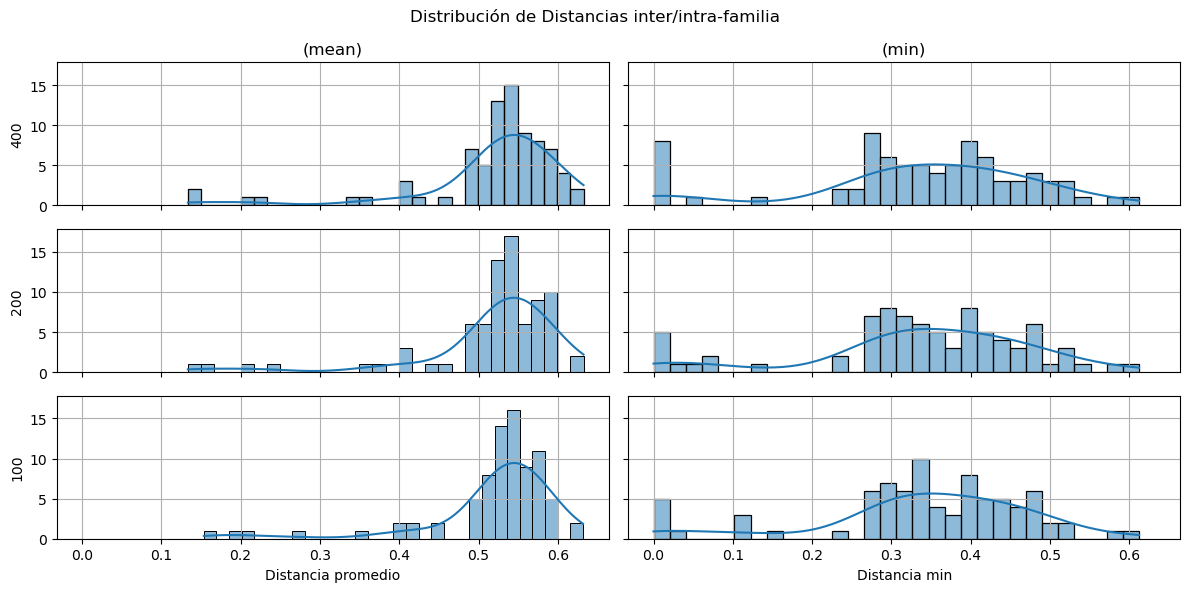

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(12, 6), sharey=True, sharex=True)

sns.histplot(df_mean_400.values.flatten(), bins=30, kde=True, ax=ax[0, 0])
sns.histplot(df_min_400.values.flatten(), bins=30, kde=True, ax=ax[0, 1])
ax[0, 0].set_title("(mean)")
ax[0, 1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia")
ax[0, 0].set_xlabel("Distancia promedio")
ax[0, 1].set_xlabel("Distancia min")
ax[0, 0].set_ylabel("400")
ax[0, 0].grid(True)
ax[0, 1].grid(True)
sns.histplot(df_mean_200.values.flatten(), bins=30, kde=True, ax=ax[1, 0])
sns.histplot(df_min_200.values.flatten(), bins=30, kde=True, ax=ax[1, 1])
ax[1, 0].set_xlabel("Distancia promedio")
ax[1, 1].set_xlabel("Distancia min")
ax[1, 0].set_ylabel("200")
ax[1, 0].grid(True)
ax[1, 1].grid(True)
sns.histplot(df_mean_100.values.flatten(), bins=30, kde=True, ax=ax[2, 0])
sns.histplot(df_min_100.values.flatten(), bins=30, kde=True, ax=ax[2, 1])
ax[2, 0].set_xlabel("Distancia promedio")
ax[2, 1].set_xlabel("Distancia min")
ax[2, 0].set_ylabel("100")
ax[2, 0].grid(True)
ax[2, 1].grid(True)
fig.tight_layout()
plt.show()

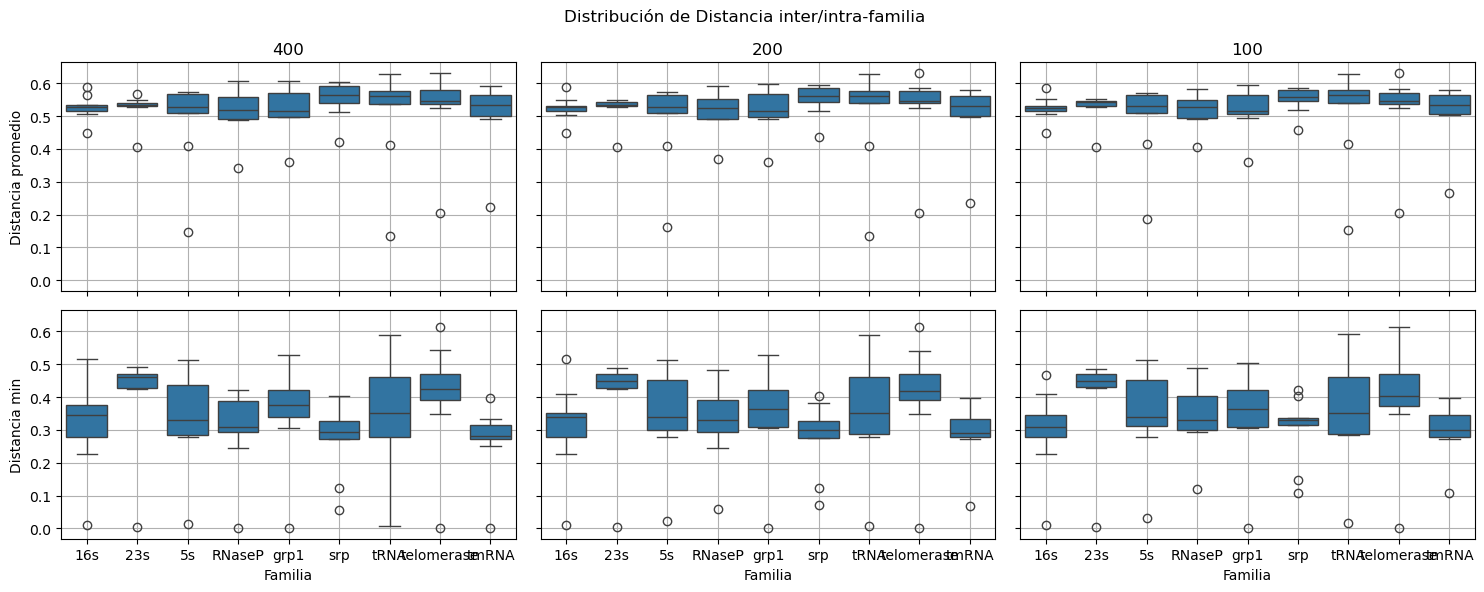

In [9]:





# Quiero trasponer los ejes x e y
fig, ax = plt.subplots(2, 3, figsize=(15, 6), sharey=True, sharex=True)
sns.boxplot(data=df_long_mean_400, x="Familia", y="Distancia", ax=ax[0, 0])
sns.boxplot(data=df_long_min_400, x="Familia", y="Distancia", ax=ax[1, 0]) 
fig.suptitle("Distribución de Distancia inter/intra-familia")
ax[0, 0].set_ylabel("Distancia promedio")
ax[1, 0].set_ylabel("Distancia min")
ax[0, 0].set_title("400")
ax[0, 0].grid(True)
ax[1, 0].grid(True)
sns.boxplot(data=df_long_mean_200, x="Familia", y="Distancia", ax=ax[0, 1])
sns.boxplot(data=df_long_min_200, x="Familia", y="Distancia", ax=ax[1, 1]) 
ax[0, 1].set_title("200")
ax[0, 1].grid(True)
ax[1, 1].grid(True)
sns.boxplot(data=df_long_mean_100, x="Familia", y="Distancia", ax=ax[0, 2])
sns.boxplot(data=df_long_min_100, x="Familia", y="Distancia", ax=ax[1, 2])
ax[0, 2].set_title("100")
ax[0, 2].grid(True)
ax[1, 2].grid(True)
fig.suptitle("Distribución de Distancia inter/intra-familia")

fig.tight_layout()
plt.show()

In [10]:
# # Creamos una copia para evitar modificar el original
# df_no_diag = df_min.copy()

# # Recorremos la diagonal y seteamos esos valores a NaN
# for i in df_no_diag.index:
#     if i in df_no_diag.columns:
#         df_no_diag.loc[i, i] = np.nan

# # Ahora calculamos el promedio por columna sin contar la diagonal (que ahora es NaN)
# column_means = df_no_diag.min()

# # Valores diagonales: Distancia intra-familia
# intra_family = pd.Series(
#     {i: df_min.loc[i, i] for i in df_min.index if i in df_min.columns}
# )

# # Juntamos todo en un DataFrame para análisis o gráfica
# comparison = pd.DataFrame(
#     {
#         "Intra": intra_family,
#         "Inter": column_means,
#     }
# ).sort_values(by="Inter")
# comparison

In [11]:
# Creamos una copia para evitar modificar el original
df_no_diag = df_mean_400.copy()

# Recorremos la diagonal y seteamos esos valores a NaN
for i in df_no_diag.index:
    if i in df_no_diag.columns:
        df_no_diag.loc[i, i] = np.nan

# Ahora calculamos el promedio por columna sin contar la diagonal (que ahora es NaN)
column_means = df_no_diag.mean()

# Valores diagonales: Distancia intra-familia
intra_family = pd.Series(
    {i: df_mean_400.loc[i, i] for i in df_mean_400.index if i in df_mean_400.columns}
)

# Juntamos todo en un DataFrame para análisis o gráfica
comparison_mean = pd.DataFrame(
    {
        "Intra": intra_family,
        "Inter": column_means,
    }
).sort_values(by="Inter")
comparison_mean

,Intra,Inter
5s,0.145733,0.527823
RNaseP,0.342883,0.531167
16s,0.449483,0.536223
23s,0.406968,0.539807
tmRNA,0.223470,0.541248
grp1,0.359681,0.542124
tRNA,0.133386,0.552356
telomerase,0.206336,0.564785
srp,0.420097,0.569723


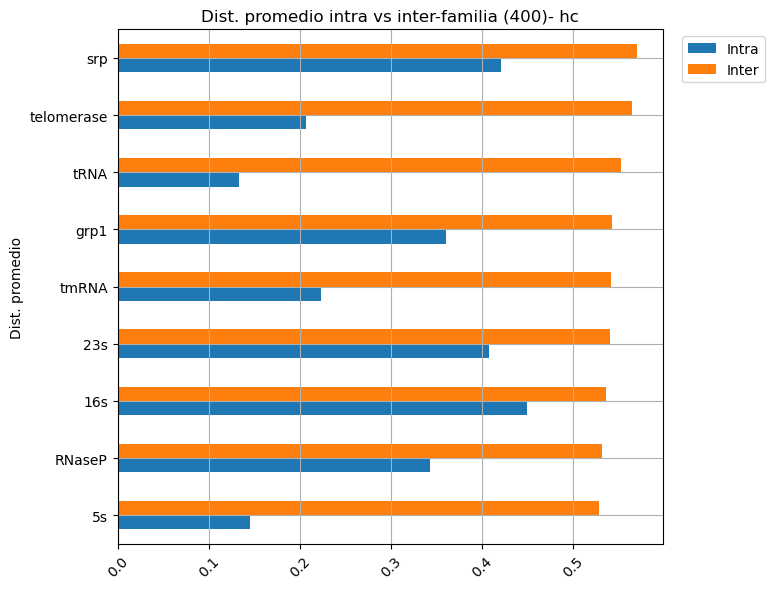

In [12]:
comparison_mean.sort_values('Inter').plot(kind="barh", figsize=(8, 6))
plt.title("Dist. promedio intra vs inter-familia (400)- hc")
plt.ylabel("Dist. promedio")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.2,1))
plt.tight_layout()
plt.show()

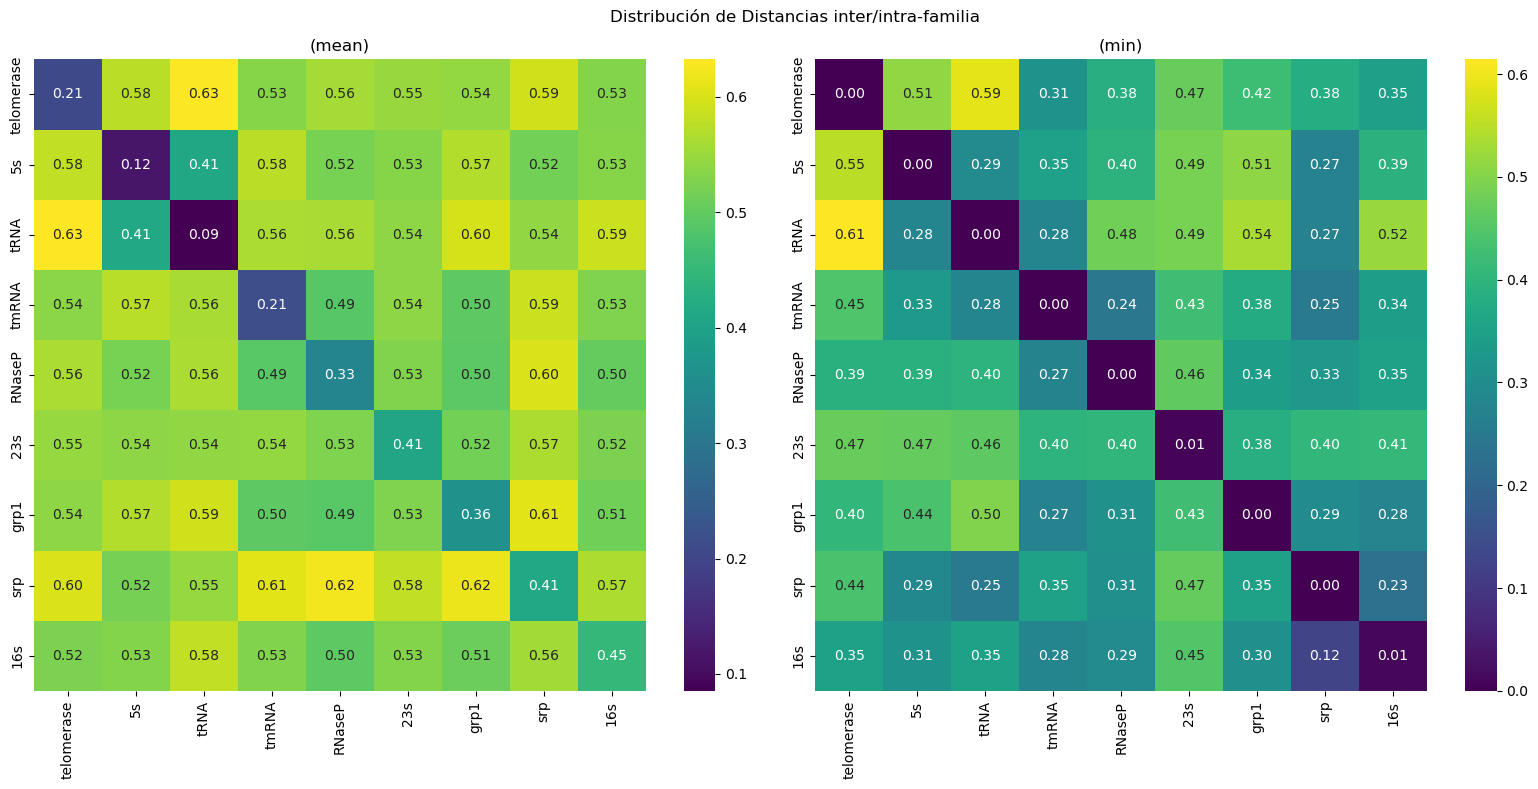

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia")

fig.tight_layout()
plt.show()

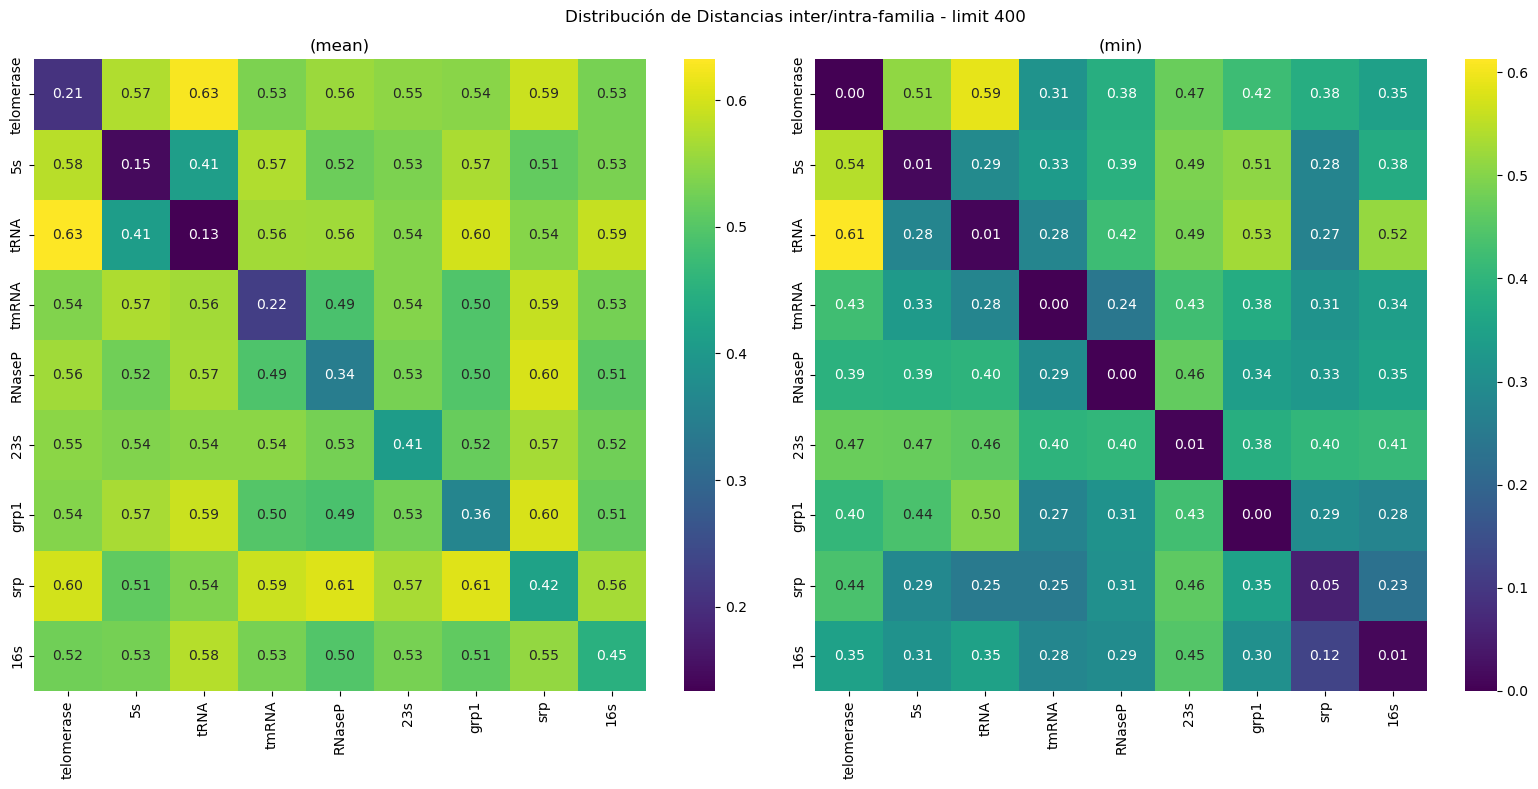

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 400")

fig.tight_layout()
plt.show()

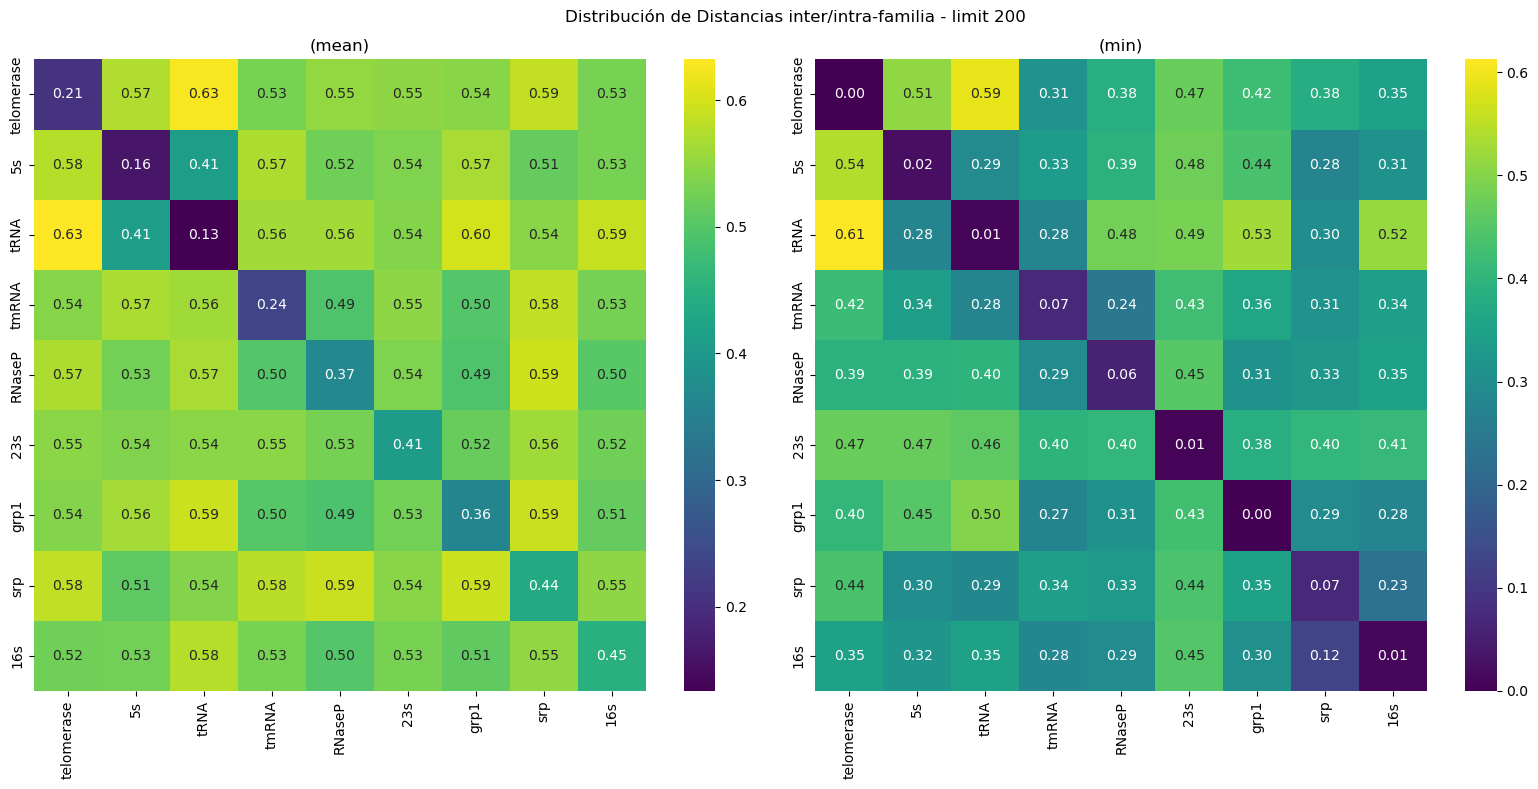

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 200")

fig.tight_layout()
plt.show()

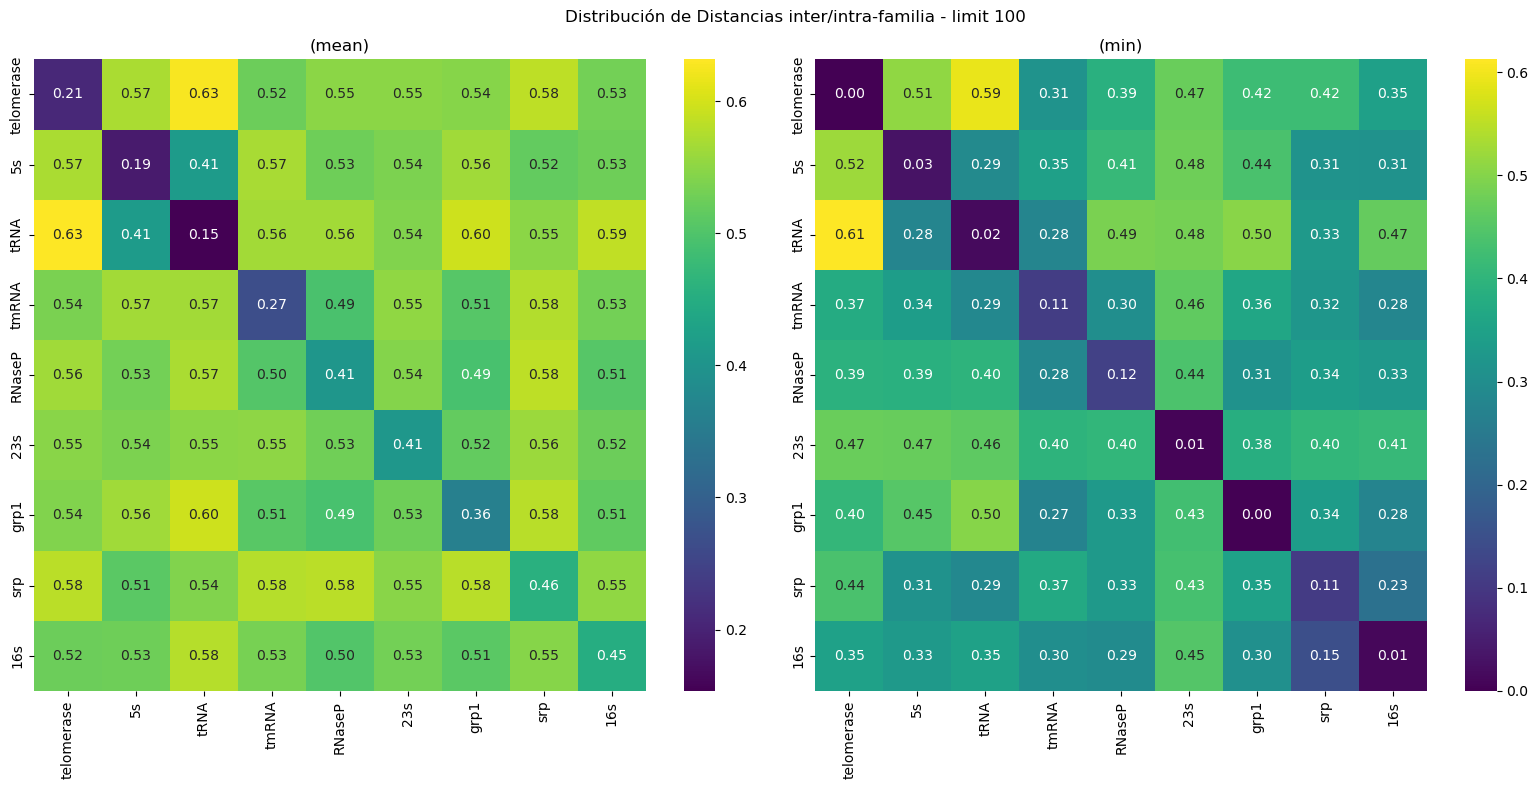

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(df_sorted_mean_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(df_sorted_min_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])
ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 100")

fig.tight_layout()
plt.show()

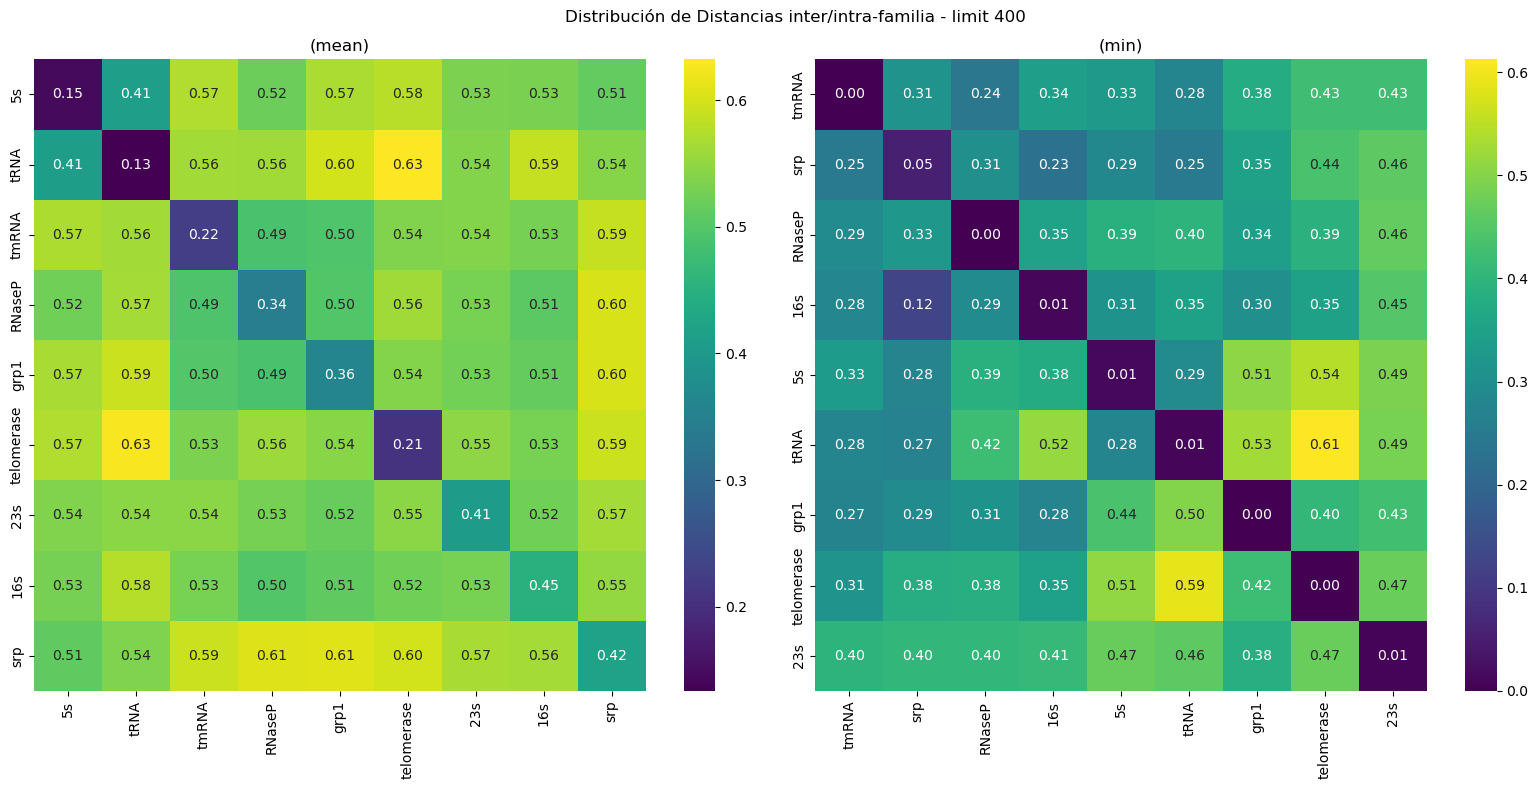

In [17]:
dfff = ru.order_matrix(df_sorted_mean_400)
dfff_sorted_min = ru.order_matrix(df_sorted_min_400)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(dfff, annot=True, fmt=".2f", cmap="viridis", ax=ax[0])
sns.heatmap(dfff_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1])


ax[0].set_title("(mean)")
ax[1].set_title("(min)")
fig.suptitle("Distribución de Distancias inter/intra-familia - limit 400")

fig.tight_layout()
plt.show()

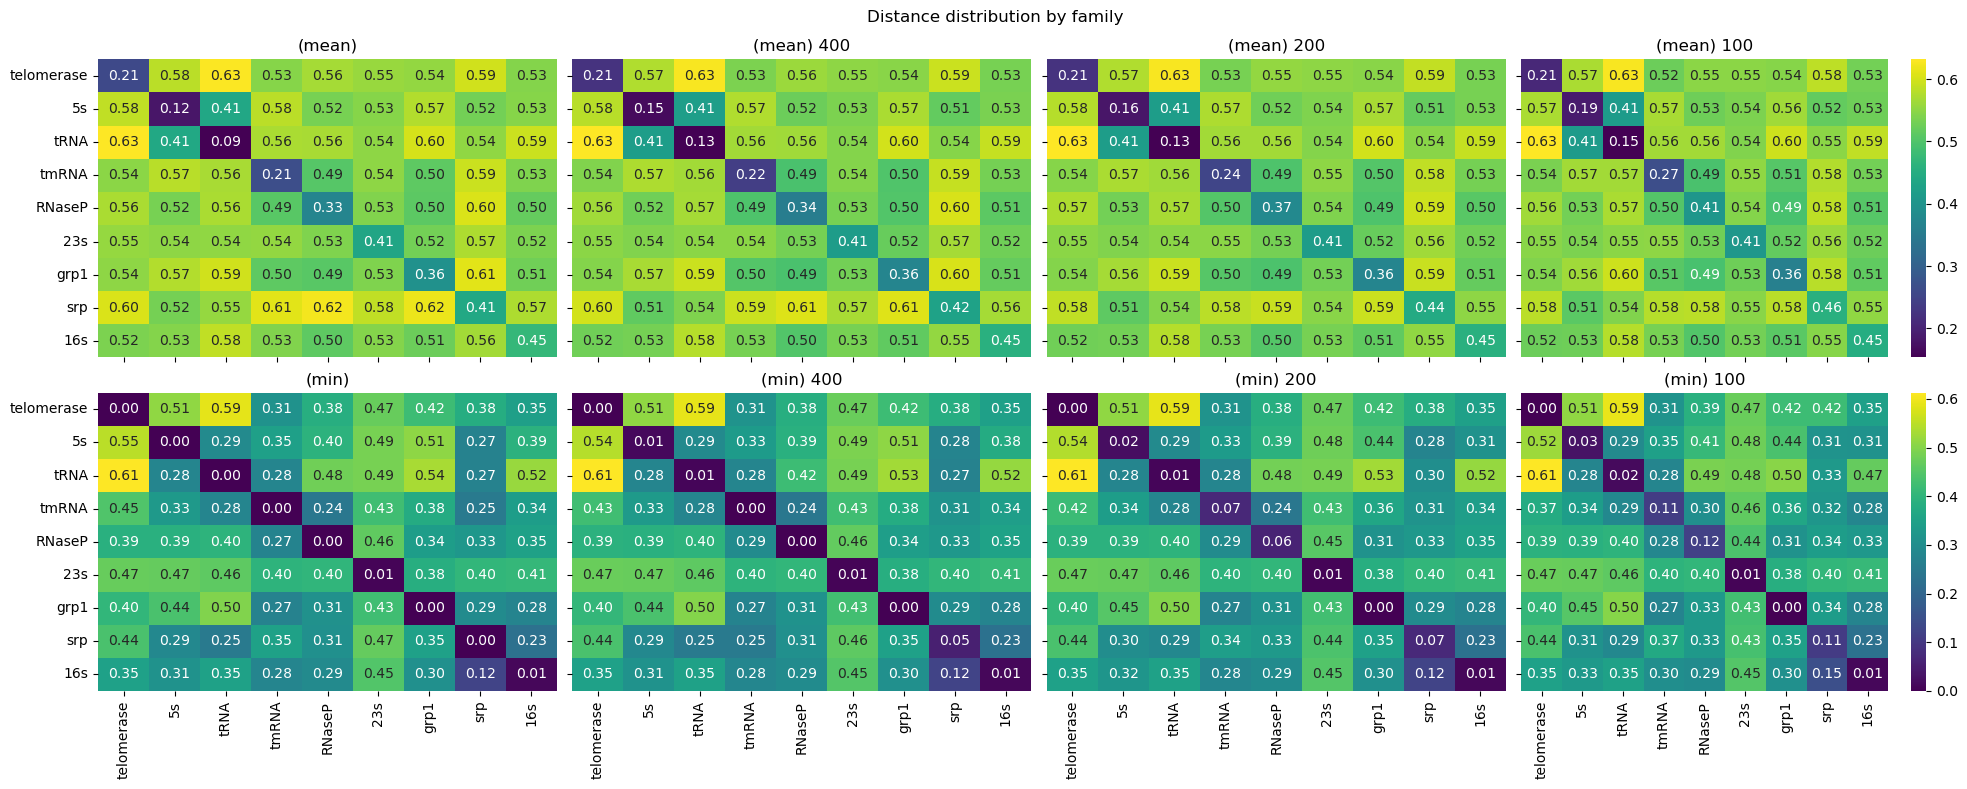

In [18]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0], cbar=False)
sns.heatmap(df_sorted_mean_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,1], cbar=False)
sns.heatmap(df_sorted_mean_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,2], cbar=False)
sns.heatmap(df_sorted_mean_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,3])
sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0], cbar=False)
sns.heatmap(df_sorted_min_400, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,1], cbar=False)
sns.heatmap(df_sorted_min_200, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,2], cbar=False)
sns.heatmap(df_sorted_min_100, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,3])
ax[0,0].set_title("(mean)")
ax[0,1].set_title("(mean) 400")
ax[0,2].set_title("(mean) 200")
ax[0,3].set_title("(mean) 100")
ax[1,0].set_title("(min)")
ax[1,1].set_title("(min) 400")
ax[1,2].set_title("(min) 200")
ax[1,3].set_title("(min) 100")
fig.suptitle("Distance distribution by family")
fig.tight_layout()
plt.show()

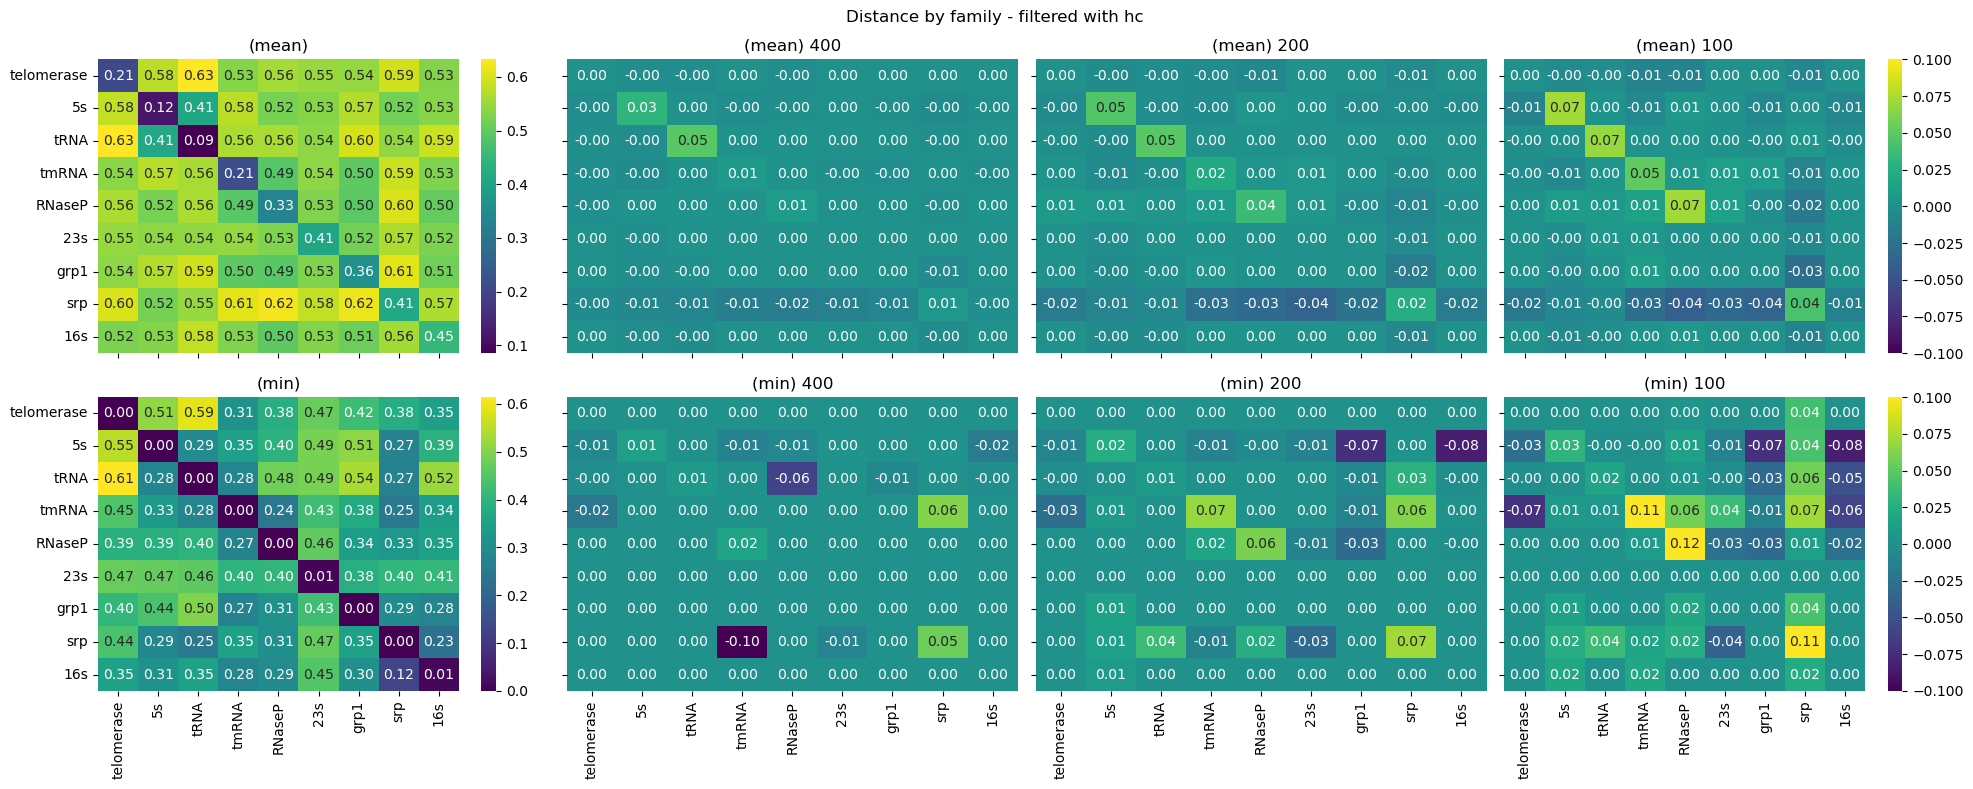

In [19]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0])

sns.heatmap((df_sorted_mean_400 - df_sorted_mean), annot=True, fmt=".2f", cmap="viridis", ax=ax[0,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_mean_200 - df_sorted_mean), annot=True, fmt=".2f", cmap="viridis", ax=ax[0,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_mean_100 - df_sorted_mean), annot=True, fmt=".2f", cmap="viridis", ax=ax[0,3], vmin=-0.1, vmax=0.1)


sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0])

sns.heatmap((df_sorted_min_400 - df_sorted_min), annot=True, fmt=".2f", cmap="viridis", ax=ax[1,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_min_200 - df_sorted_min), annot=True, fmt=".2f", cmap="viridis", ax=ax[1,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap((df_sorted_min_100 - df_sorted_min), annot=True, fmt=".2f", cmap="viridis", ax=ax[1,3], vmin=-0.1, vmax=0.1)
ax[0,0].set_title("(mean)")
ax[0,1].set_title("(mean) 400")
ax[0,2].set_title("(mean) 200")
ax[0,3].set_title("(mean) 100")
ax[1,0].set_title("(min)")
ax[1,1].set_title("(min) 400")
ax[1,2].set_title("(min) 200")
ax[1,3].set_title("(min) 100")
fig.suptitle("Distance by family - filtered with hc")
fig.tight_layout()
plt.show()

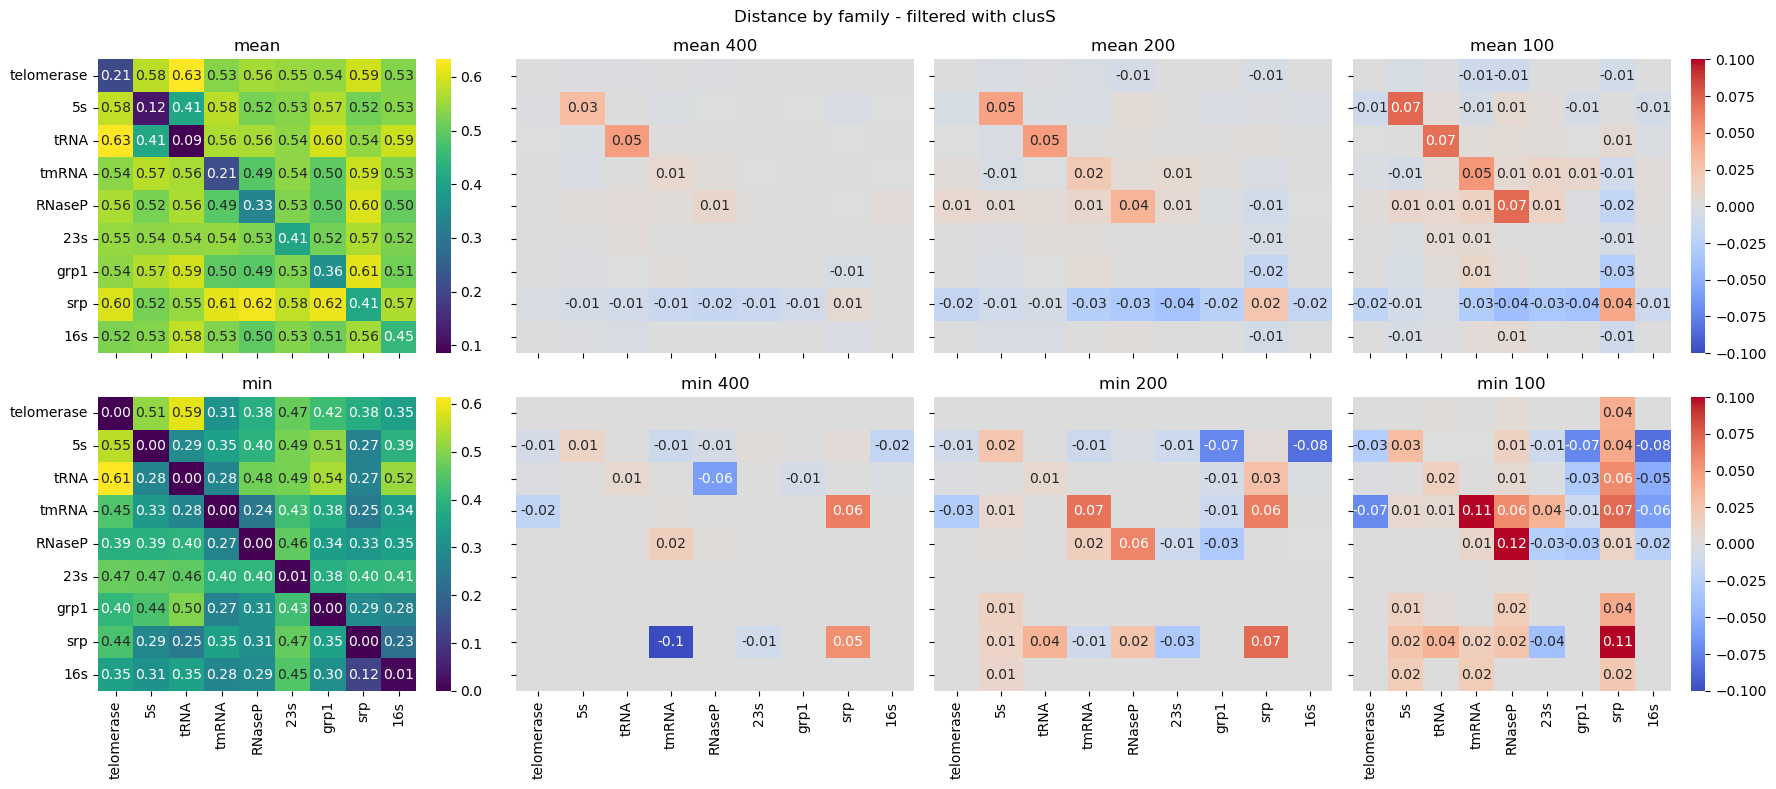

In [25]:
def annot_no_zeros(mat, fmt=".2f"):
    """Devuelve matriz de strings, con '' cuando el valor es 0."""
    return np.where(np.round(mat, 2) == 0, "", mat.astype(float).round(2).astype(str))


fig, ax = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
sns.heatmap(df_sorted_mean, annot=True, fmt=".2f", cmap="viridis", ax=ax[0,0])

delta_mean_400 = df_sorted_mean_400 - df_sorted_mean
delta_mean_200 = df_sorted_mean_200 - df_sorted_mean
delta_mean_100 = df_sorted_mean_100 - df_sorted_mean
sns.heatmap(delta_mean_400, annot=  annot_no_zeros(delta_mean_400), fmt="", cmap="coolwarm", ax=ax[0,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_mean_200, annot=  annot_no_zeros(delta_mean_200), fmt="", cmap="coolwarm", ax=ax[0,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_mean_100, annot=  annot_no_zeros(delta_mean_100), fmt="", cmap="coolwarm", ax=ax[0,3], vmin=-0.1, vmax=0.1)


sns.heatmap(df_sorted_min, annot=True, fmt=".2f", cmap="viridis", ax=ax[1,0])

delta_min_400 = df_sorted_min_400 - df_sorted_min
delta_min_200 = df_sorted_min_200 - df_sorted_min
delta_min_100 = df_sorted_min_100 - df_sorted_min
sns.heatmap(delta_min_400, annot= annot_no_zeros(delta_min_400), fmt="", cmap="coolwarm", ax=ax[1,1], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_min_200, annot= annot_no_zeros(delta_min_200), fmt="", cmap="coolwarm", ax=ax[1,2], cbar=False, vmin=-0.1, vmax=0.1)
sns.heatmap(delta_min_100, annot= annot_no_zeros(delta_min_100), fmt="", cmap="coolwarm", ax=ax[1,3], vmin=-0.1, vmax=0.1)


ax[0,0].set_title("mean")
ax[0,1].set_title("mean 400")
ax[0,2].set_title("mean 200")
ax[0,3].set_title("mean 100")
ax[1,0].set_title("min")
ax[1,1].set_title("min 400")
ax[1,2].set_title("min 200")
ax[1,3].set_title("min 100")
fig.suptitle("Distance by family - filtered with clusS")
fig.tight_layout()
plt.show()